In [62]:
import xarray as xr
import numpy as np
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from shapely.geometry import box
import shapely.vectorized as sv
import matplotlib.pyplot as plt
import pandas as pd

In [63]:
def average_capacity_factors(filename):
    '''
    Function to read in a .nc file and calculate the average capacity factors over time.
    '''
    ds = xr.open_dataset(filename)

    cf_avg = ds.mean(dim='time')

    return cf_avg

def get_top_60_percent_cfs(avg_capacity_factors):
    '''
    Function to get the top 60% of capacity factors.
    '''
    # quantile(skipna=True) only looks at non-NaN cells in avg_capacity_factors --
    # so if this was clipped to a zone (e.g. LRZ1) upstream, only that zone's
    # cells are considered here, not the full MISO grid
    cfs_60 = avg_capacity_factors.where(avg_capacity_factors > avg_capacity_factors.quantile(0.01, skipna=True), -1)

    # Assuming 'variable_name' is the name of the variable in the Dataset
    num_cfs_60 = cfs_60['capacity factor'].where(cfs_60['capacity factor'] != -1).notnull().sum().item()
    print(f"Number of grid cells in the top 60%: {num_cfs_60}/{cfs_60['capacity factor'].size}")

    return cfs_60

In [64]:
def get_time_series_top_60_percent_cfs(filename, cfs_60, cf_type):
    '''
    Function to get the time series of the top 60% of capacity factors.
    '''
    ds = xr.open_dataset(filename)

    # Save average over all grid cells to csv file
    ds_avg = ds.mean(dim=['x', 'y'])
    ds_avg_df = ds_avg.to_dataframe()
    ds_avg_df = ds_avg_df.rename(columns={'capacity factor': f'{cf_type}_cf_avg'})
    year = filename.split('_')[-1].split('.')[0]
    # ds_avg_df.to_csv(f'CONUS_{cf_type}_CF_avg_all_{year}.csv')

    # Get time series of top 60% grid cells
    cfs_60_ts = ds.where(cfs_60 > 0)

    # Average over all grid cells
    cfs_60_ts = cfs_60_ts.mean(dim=['x', 'y'])

    # Write to csv file
    cfs_60_df = cfs_60_ts.to_dataframe()

    # Drop columns execpt for time and capacity factor
    cfs_60_df = cfs_60_df.drop(columns=['quantile'])
    # Rename columns
    cfs_60_df = cfs_60_df.rename(columns={'capacity factor': f'{cf_type}_cf'})
    
    # Write to csv file
    year = filename.split('_')[-1].split('.')[0]
    cfs_60_df.to_csv(f'CONUS_{cf_type}_CF_{year}.csv')

In [65]:
def plot_capacity_factor(cf, cap_fac_type):
    from shapely.validation import make_valid

    miso = gpd.read_file("/Users/mshaaban/clab_underground_th_storage/data_folder/miso_shapefile.geojson")
    if miso.crs is None or miso.crs.to_epsg() != 4326:
        miso = miso.to_crs(epsg=4326)
    #miso_geom = miso.geometry.union_all()

        # Fix invalid geometries
    miso["geometry"] = miso["geometry"].apply(make_valid)
    miso_geom = miso.geometry.union_all()

    lon, lat = np.meshgrid(cf['x'], cf['y'])
    mask = sv.contains(miso_geom, lon, lat)
    masked_dataset = cf.where(mask)

    aspect_ratio = (cf['x'].max()-cf['x'].min())/(cf['y'].max()-cf['y'].min())
    masked_dataset["capacity factor"].plot(aspect=aspect_ratio, size=5, vmin=0.)
    plt.title(f'{cap_fac_type} MISO average')
    plt.savefig(f'capacity_factor_MISO_{cap_fac_type.replace(" ","").replace("%","")}.jpg')
    print(masked_dataset["capacity factor"].where(masked_dataset["capacity factor"] > 0).mean().values)

In [66]:
def clip_dataset_to_zone(ds, zone_geojson_path):
    """
    Actually shrink an xarray Dataset down to the grid cells inside a zone
    polygon (e.g. LRZ1), instead of just masking values to NaN.

    A plain .where(mask) keeps every grid cell in the array -- it just sets
    the excluded ones to NaN, so array.size (and any "X out of Y grid cells"
    count) never changes no matter what geometry you mask with. This trims
    the 'x'/'y' coordinate arrays down to the zone's bounding box first, so
    the resulting dataset's actual shape shrinks, then masks the remaining
    cells that still fall outside the polygon (bounding boxes aren't exact
    for irregular zone shapes).
    """
    from shapely.validation import make_valid

    zone = gpd.read_file(zone_geojson_path)
    if zone.crs is None or zone.crs.to_epsg() != 4326:
        zone = zone.to_crs(epsg=4326)
    zone["geometry"] = zone["geometry"].apply(make_valid)
    zone_geom = zone.geometry.union_all()

    minx, miny, maxx, maxy = zone_geom.bounds

    # x/y coords can be ascending or descending -- .sel(slice(...)) needs the
    # slice to go the same direction as the coordinate array or it returns empty
    x_vals = ds['x'].values
    y_vals = ds['y'].values
    x_slice = slice(minx, maxx) if x_vals[0] < x_vals[-1] else slice(maxx, minx)
    y_slice = slice(miny, maxy) if y_vals[0] < y_vals[-1] else slice(maxy, miny)

    ds_clip = ds.sel(x=x_slice, y=y_slice)

    if ds_clip['x'].size == 0 or ds_clip['y'].size == 0:
        raise ValueError(
            "Clipping produced an empty grid -- check that the zone geojson's "
            "CRS/bounds actually overlap the .nc file's x/y coordinates."
        )

    # Bounding box isn't exact for irregular polygons, so also null out the
    # handful of remaining cells whose centers fall outside the actual shape
    lon, lat = np.meshgrid(ds_clip['x'], ds_clip['y'])
    mask = sv.contains(zone_geom, lon, lat)
    ds_clip = ds_clip.where(mask)

    print(f"Clipped grid: {ds_clip['x'].size} x cells x {ds_clip['y'].size} y cells "
          f"= {ds_clip['x'].size * ds_clip['y'].size} total (vs {ds['x'].size * ds['y'].size} before clipping)")

    return ds_clip

In [67]:
def get_60_percent_cf_all(cf_type, zone_geojson_path=None):
    """
    Get the top 60% capacity factors for all years.

    If zone_geojson_path is given (e.g. your LRZ1 shapefile/geojson), each
    .nc file is clipped down to just that zone's grid cells immediately
    after it's opened -- so averaging, the top-X% cutoff, plotting, and the
    output time series all operate on the smaller zone-only grid rather than
    the full MISO footprint.
    """

    def load_and_clip(year):
        ds = xr.open_dataset(f'miso_{cf_type}_CF_timeseries_{year}.nc')
        if zone_geojson_path is not None:
            ds = clip_dataset_to_zone(ds, zone_geojson_path)
        return ds

    cf_avg_2020 = load_and_clip(2020).mean(dim='time')
    cf_avg_2021 = load_and_clip(2021).mean(dim='time')
    cf_avg_2022 = load_and_clip(2022).mean(dim='time')
    cf_avg_2024 = load_and_clip(2024).mean(dim='time')
    cf_avg_2023 = load_and_clip(2023).mean(dim='time')

    cf_avg_all = (cf_avg_2020 + cf_avg_2021 + cf_avg_2022 + cf_avg_2023 + cf_avg_2024)/5

    # Plot
    plot_capacity_factor(cf_avg_all, cf_type)
    cf_all_60 = get_top_60_percent_cfs(cf_avg_all)
    plot_capacity_factor(cf_all_60, cf_type+" top 60%")

    cfs = []
    for year in range(2020, 2025):

        cf_ts = load_and_clip(year)

        # Only keep the capacity factors that are non-zero in cf_all_60
        cf_ts = cf_ts.where(cf_all_60 > -1)

        # Average over all grid cells
        cf_ts = cf_ts.mean(dim=['x', 'y'])

        cfs.append(cf_ts)

    cf_ts_all = xr.concat(cfs, dim='time')
    # Drop quantile dimension
    cf_ts_all = cf_ts_all.drop_vars('quantile', errors='ignore')
    # Rename capacity factor dimension
    cf_ts_all = cf_ts_all.rename({'capacity factor': f'{cf_type}_cf'})
    # Write to csv file
    cf_ts_all_df = cf_ts_all.to_dataframe()
    if zone_geojson_path is None:
        suffix = ""
    else:
        import os
        zone_name = os.path.splitext(os.path.basename(zone_geojson_path))[0]
        suffix = f"_{zone_name}"
    cf_ts_all_df.to_csv(f'MISO_{cf_type}_CF_2020_2024{suffix}.csv')

/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 38 x cells x 32 y cells = 1216 total (vs 7998 before clipping)


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 38 x cells x 32 y cells = 1216 total (vs 7998 before clipping)


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


...

/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 38 x cells x 32 y cells = 1216 total (vs 7998 before clipping)


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


Clipped grid: 38 x cells x 32 y cells = 1216 total (vs 7998 before clipping)
Clipped grid: 38 x cells x 32 y cells = 1216 total (vs 7998 before clipping)


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/2702466084.py:42: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(zone_geom, lon, lat)


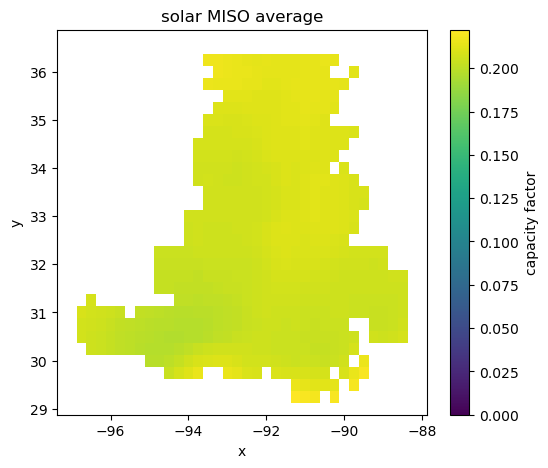

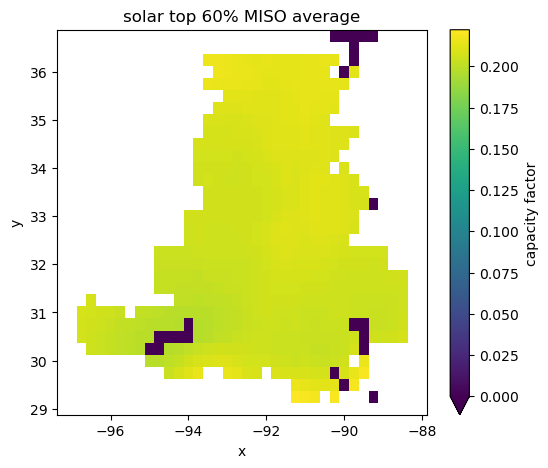

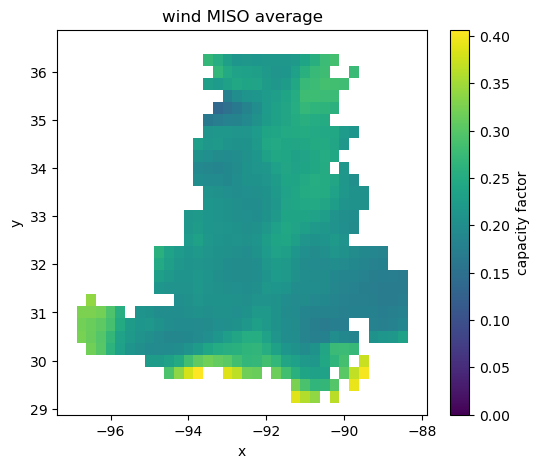

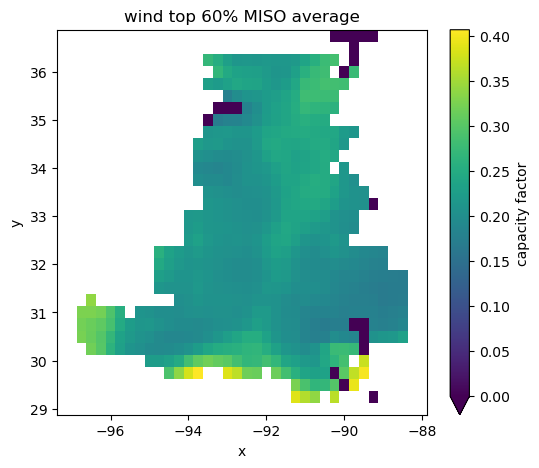

In [68]:
# Example: run for LRZ1 only, instead of the whole MISO footprint
lrz1_geojson_path = "/Users/mshaaban/clab_underground_th_storage/maping/8,9,10/8910.geojson"  # <-- update this

get_60_percent_cf_all('solar', zone_geojson_path=lrz1_geojson_path)
get_60_percent_cf_all('wind', zone_geojson_path=lrz1_geojson_path)

/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/3102098056.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.21009046238830764
Number of grid cells in the top 60%: 7918/7998


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/3102098056.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.21009046238830764


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/3102098056.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.34940612431309814
Number of grid cells in the top 60%: 7918/7998


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_7964/3102098056.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.34940612431309814


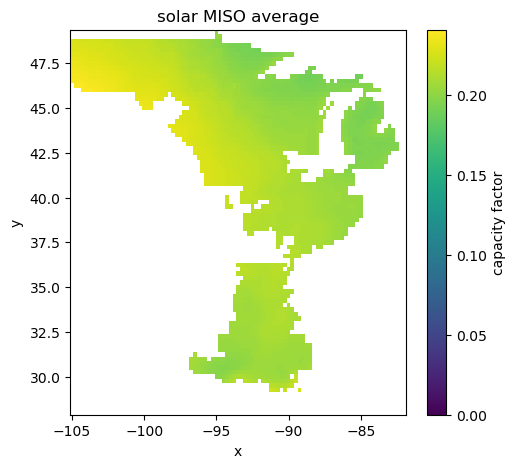

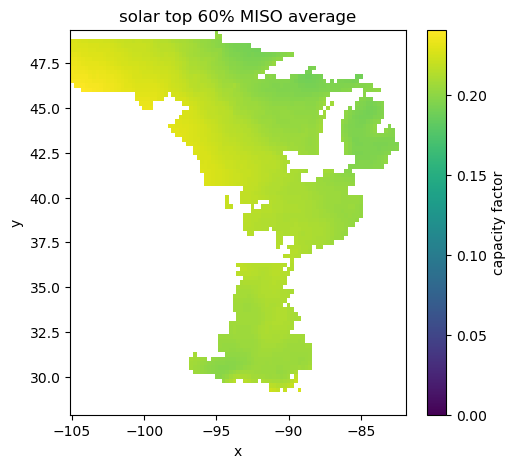

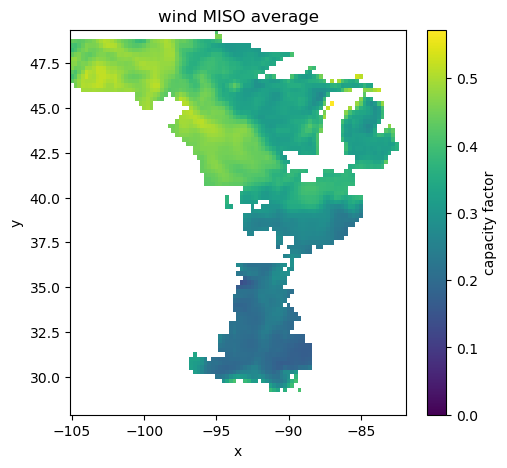

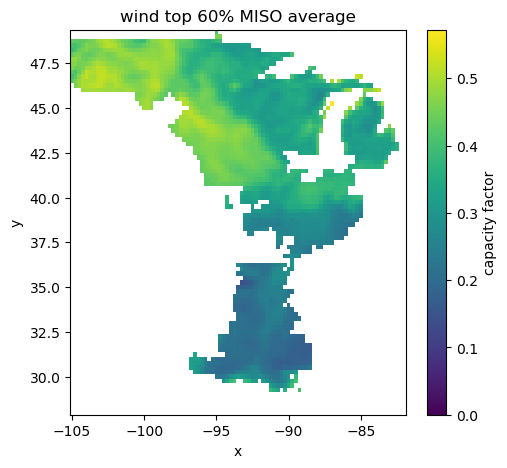

In [69]:
get_60_percent_cf_all('solar')
get_60_percent_cf_all('wind')

In [70]:
def read_csv_file(filename):
    """
    Read csv file
    """
    df = pd.read_csv(filename)
    # Print mean of columm 1
    print(df.iloc[:,1].mean())

# Source for reported capacity factors:
# https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=table_6_07_b
print("Solar")
print("Reported 5 year average of capacity factors")
print((20.38+22.26+23.03+22.83+21.81)/5./100.)
print("Mean capacity factor of top 60% of grid cells")
read_csv_file('MISO_solar_CF_2020_2024.csv')

print("\n")
print("Wind")
print("Reported 5 year average of capacity factors")
print((31.66+32.13+36.65+31.76+33.15)/5./100.)
print("Mean capacity factor of top 60% of grid cells")
read_csv_file('MISO_wind_CF_2020_2024.csv')

Solar
Reported 5 year average of capacity factors
0.22062
Mean capacity factor of top 60% of grid cells
0.22075546090601247


Wind
Reported 5 year average of capacity factors
0.3307
Mean capacity factor of top 60% of grid cells
0.35664698415128343


In [71]:
def read_csv_file(filename):
    """
    Read csv file
    """
    df = pd.read_csv(filename)
    # Print mean of column 1
    print(df.iloc[:, 1].mean())


def print_zone_cf_summary(zone_geojson_path=None):
    """
    Prints mean solar and wind capacity factor for a given zone, using the
    same filename convention as get_60_percent_cf_all: no suffix for the
    full MISO footprint, or "_<zone filename>" for a clipped zone.
    """
    if zone_geojson_path is None:
        suffix = ""
        label = "MISO (full)"
    else:
        import os
        zone_name = os.path.splitext(os.path.basename(zone_geojson_path))[0]
        suffix = f"_{zone_name}"
        label = zone_name

    print(f"=== {label} ===")

    print("Solar")
    print("Mean capacity factor of top 60% of grid cells")
    read_csv_file(f'MISO_solar_CF_2020_2024{suffix}.csv')

    print("\n")
    print("Wind")
    print("Mean capacity factor of top 60% of grid cells")
    read_csv_file(f'MISO_wind_CF_2020_2024{suffix}.csv')
    print("\n")

In [ ]:
print_zone_cf_summary()  # full MISO
print_zone_cf_summary('/Users/mshaaban/clab_underground_th_storage/maping/8,9,10/8910.geojson')

=== MISO (full) ===
Solar
Mean capacity factor of top 60% of grid cells
0.22075546090601247


Wind
Mean capacity factor of top 60% of grid cells
0.35664698415128343


=== LRZ1 ===
Solar
Mean capacity factor of top 60% of grid cells
0.22075546090601247


Wind
Mean capacity factor of top 60% of grid cells
0.35664698415128343


=== LRZ2 ===
Solar
Mean capacity factor of top 60% of grid cells


FileNotFoundError: [Errno 2] No such file or directory: 'MISO_solar_CF_2020_2024_LRZ2.csv'